<a href="https://colab.research.google.com/github/sreejas7919-bit/DSA_6/blob/main/unsupervised_casestudy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# UNSUPERVISED LEARNING CASE STUDY

In [6]:
# Step 1: Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import linkage, dendrogram

In [7]:
df = pd.read_csv("/content/adult_dataset.csv")

In [8]:
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39.0,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40.0,NaN,<=50K
1,50.0,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13.0,United-States,<=50K
2,38.0,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40.0,United-States,<=50K
3,53.0,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40.0,United-States,<=50K
4,28.0,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40.0,Cuba,<=50K


In [9]:
df.shape

(48842, 15)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             46400 non-null  float64
 1   workclass       45480 non-null  object 
 2   fnlwgt          48842 non-null  int64  
 3   education       48842 non-null  object 
 4   education-num   48842 non-null  int64  
 5   marital-status  48842 non-null  object 
 6   occupation      45485 non-null  object 
 7   relationship    48842 non-null  object 
 8   race            48842 non-null  object 
 9   sex             48842 non-null  object 
 10  capital-gain    48842 non-null  int64  
 11  capital-loss    48842 non-null  int64  
 12  hours-per-week  46400 non-null  float64
 13  native-country  46137 non-null  object 
 14  income          48842 non-null  object 
dtypes: float64(2), int64(4), object(9)
memory usage: 5.6+ MB


In [11]:
df.describe()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,46400.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,46400.000000
mean,38.679116,1.896641e+05,10.078089,1079.067626,87.502314,40.448599
std,13.952954,1.056040e+05,2.570973,7452.019058,403.004552,12.646992
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000
max,255.000000,1.490400e+06,16.000000,99999.000000,4356.000000,250.000000


In [12]:
#check missing values
df.isnull().sum()

,0
age,2442
workclass,3362
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,3357
relationship,0
race,0
sex,0


In [13]:
# Step 6: Replace ? with NaN

df.replace("?", np.nan, inplace=True)

In [14]:
# Step 8: Fill Missing Values

df["workclass"].fillna(df["workclass"].mode()[0], inplace=True)

df["occupation"].fillna(df["occupation"].mode()[0], inplace=True)

df["native-country"].fillna(df["native-country"].mode()[0], inplace=True)

df["age"].fillna(df["age"].median(), inplace=True)

df["hours-per-week"].fillna(df["hours-per-week"].median(), inplace=True)

/tmp/ipykernel_37886/2719432166.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["workclass"].fillna(df["workclass"].mode()[0], inplace=True)
/tmp/ipykernel_37886/2719432166.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inp

In [15]:
# Step 9: Check Missing Values

df.isnull().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,0
relationship,0
race,0
sex,0


In [16]:
# Step 10: Label Encoding

le = LabelEncoder()

df["workclass"] = le.fit_transform(df["workclass"])
df["education"] = le.fit_transform(df["education"])
df["marital-status"] = le.fit_transform(df["marital-status"])
df["occupation"] = le.fit_transform(df["occupation"])
df["relationship"] = le.fit_transform(df["relationship"])
df["race"] = le.fit_transform(df["race"])
df["sex"] = le.fit_transform(df["sex"])
df["native-country"] = le.fit_transform(df["native-country"])
df["income"] = le.fit_transform(df["income"])

In [17]:
# Step 11: Check Dataset

df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39.0,6,77516,9,13,4,0,1,4,1,2174,0,40.0,38,0
1,50.0,5,83311,9,13,2,3,0,4,1,0,0,13.0,38,0
2,38.0,3,215646,11,9,0,5,1,4,1,0,0,40.0,38,0
3,53.0,3,234721,1,7,2,5,0,2,1,0,0,40.0,38,0
4,28.0,3,338409,9,13,2,9,5,2,0,0,0,40.0,4,0


In [18]:
# Step 12: Outlier Detection (IQR)

num_cols = ["age","fnlwgt","education-num",
            "capital-gain","capital-loss","hours-per-week"]

Q1 = df[num_cols].quantile(0.25)
Q3 = df[num_cols].quantile(0.75)

IQR = Q3 - Q1

In [19]:
# Step 13: Remove Outliers

df = df[~((df[num_cols] < (Q1 - 1.5*IQR)) |
          (df[num_cols] > (Q3 + 1.5*IQR))).any(axis=1)]

In [20]:
# Step 14: Shape

df.shape

(29086, 15)

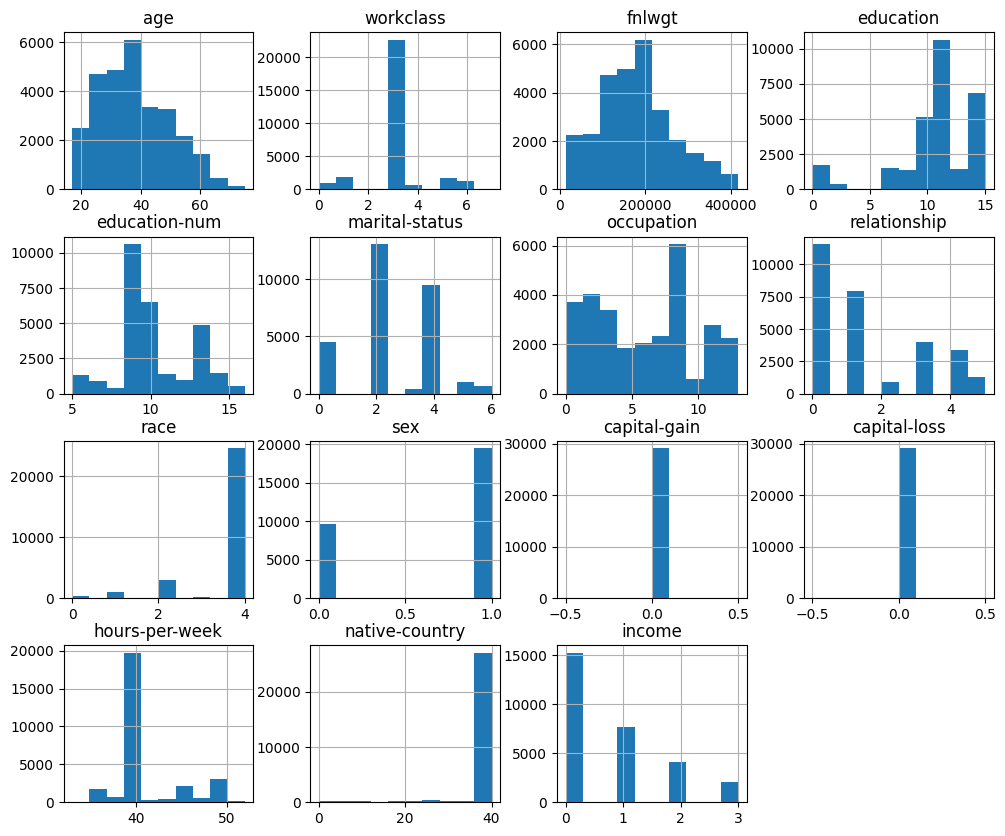

In [21]:
# Step 16: Feature Distribution

df.hist(figsize=(12,10))
plt.show()

In [22]:
# Step 17: Correlation

corr = df.corr()

corr

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
age,1.000000,0.013667,-0.067700,-0.014177,0.054327,-0.286078,-0.006135,-0.218445,0.021440,0.055959,NaN,NaN,0.055756,-0.000232,0.205155
workclass,0.013667,1.000000,-0.023348,-0.002753,-0.002649,-0.010424,0.014603,-0.040647,0.049497,0.052200,NaN,NaN,0.048669,-0.014213,-0.010420
fnlwgt,-0.067700,-0.023348,1.000000,-0.005326,-0.022490,0.035051,-0.001799,0.007699,-0.008622,0.020284,NaN,NaN,-0.016686,-0.043410,0.000448
education,-0.014177,-0.002753,-0.005326,1.000000,0.238981,-0.021530,-0.035501,0.004324,0.013644,-0.033556,NaN,NaN,0.021674,0.042212,0.041160
education-num,0.054327,-0.002649,-0.022490,0.238981,1.000000,-0.024105,0.093918,-0.090686,0.025700,-0.008853,NaN,NaN,0.128200,-0.009374,0.255467
marital-status,-0.286078,-0.010424,0.035051,-0.021530,-0.024105,1.000000,0.030173,0.160745,-0.077633,-0.081666,NaN,NaN,-0.085684,-0.016372,-0.142207
occupation,-0.006135,0.014603,-0.001799,-0.035501,0.093918,0.030173,1.000000,-0.053422,-0.002485,0.070139,NaN,NaN,0.045250,-0.001820,0.040326
relationship,-0.218445,-0.040647,0.007699,0.004324,-0.090686,0.160745,-0.053422,1.000000,-0.132821,-0.570323,NaN,NaN,-0.175568,-0.008369,-0.212208
race,0.021440,0.049497,-0.008622,0.013644,0.025700,-0.077633,-0.002485,-0.132821,1.000000,0.105484,NaN,NaN,0.089558,0.129134,0.062710
sex,0.055959,0.052200,0.020284,-0.033556,-0.008853,-0.081666,0.070139,-0.570323,0.105484,1.000000,NaN,NaN,0.172171,0.004236,0.177967


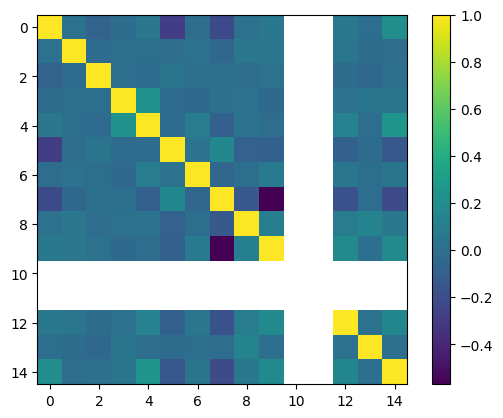

In [23]:
# Step 18: Correlation Plot

plt.imshow(corr)
plt.colorbar()
plt.show()

In [24]:
# Step 19: Separate Features

X = df.drop("income", axis=1)

In [25]:
# Step 20: Feature Scaling

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [26]:
# Step 21: PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

In [27]:
# Step 22: Elbow Method

wcss = []

for i in range(2,11):

    km = KMeans(n_clusters=i, random_state=42)

    km.fit(X_scaled)

    wcss.append(km.inertia_)

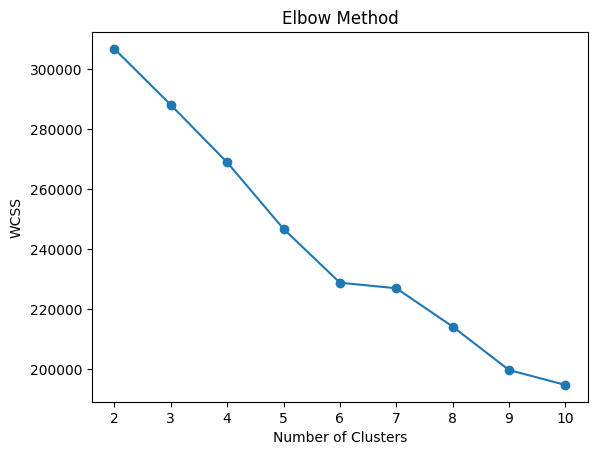

In [23]:
# Step 23: Elbow Graph

plt.plot(range(2,11), wcss, marker='o')

plt.xlabel("Number of Clusters")

plt.ylabel("WCSS")

plt.title("Elbow Method")

plt.show()

In [28]:
# Step 24: K-Means

kmeans = KMeans(n_clusters=4, random_state=42)

labels = kmeans.fit_predict(X_scaled)

In [29]:
# Step 25: Silhouette Score

score = silhouette_score(X_scaled, labels)

print(score)

0.11908621572132876


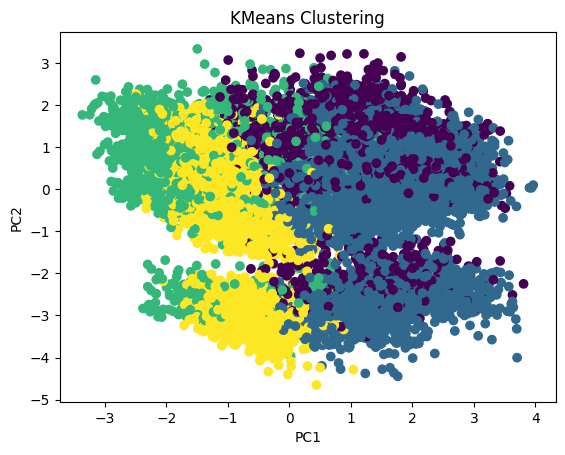

In [30]:
# Step 26: K-Means Scatter Plot

plt.scatter(X_pca[:,0], X_pca[:,1], c=labels)

plt.xlabel("PC1")

plt.ylabel("PC2")

plt.title("KMeans Clustering")

plt.show()

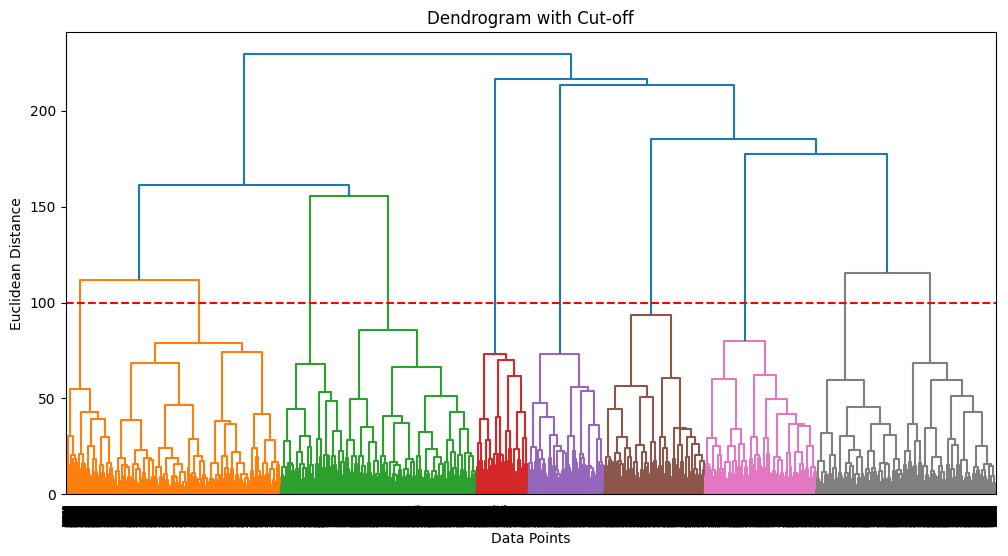

In [37]:
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt

mergings = linkage(X_scaled, method='ward')

plt.figure(figsize=(12,6))

dendrogram(mergings)

plt.axhline(y=100, color='r', linestyle='--') # Add a red dashed horizontal line
plt.title("Dendrogram with Cut-off")
plt.xlabel("Data Points")
plt.ylabel("Euclidean Distance")

plt.show()

In [31]:
agg=AgglomerativeClustering(n_clusters=4)

agg_labels=agg.fit_predict(X_scaled)

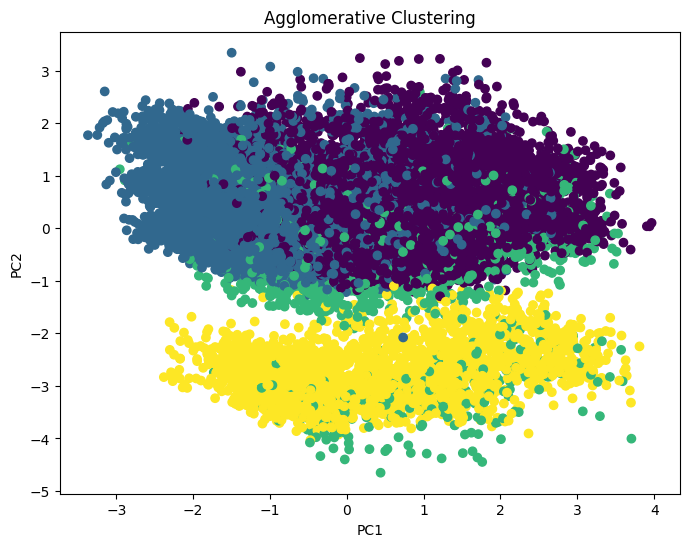

In [32]:
plt.figure(figsize=(8,6))

plt.scatter(X_pca[:,0],X_pca[:,1],c=agg_labels)

plt.xlabel("PC1")

plt.ylabel("PC2")

plt.title("Agglomerative Clustering")

plt.show()

In [33]:
df["Cluster"]=labels

In [34]:
df.groupby("Cluster").mean()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
Cluster,,,,,,,,,,,,,,,
0,41.263830,2.952520,173928.577828,10.764838,10.159910,0.651736,5.277492,3.402464,3.601344,0.089810,0.0,0.0,40.337514,36.768869,0.651960
1,30.757393,2.977898,187065.979454,10.459064,9.970530,4.196327,5.981530,2.295424,3.483345,0.467884,0.0,0.0,39.776694,36.562312,0.385286
2,38.973047,3.215203,176289.331438,10.831333,11.046326,2.333754,6.731312,0.540324,3.861234,0.911560,0.0,0.0,48.535692,37.148242,1.087597
3,42.669272,3.046019,179025.106888,10.320371,10.159648,1.942648,6.046507,0.179384,3.724963,0.998241,0.0,0.0,39.977528,36.527797,0.990034


In [35]:
pd.crosstab(df["Cluster"],df["income"])

income,0,1,2,3
Cluster,,,,
0,2502,1240,498,225
1,6207,3222,133,75
2,1970,994,1184,601
3,4606,2245,2264,1120


In [ ]:
#compare graph


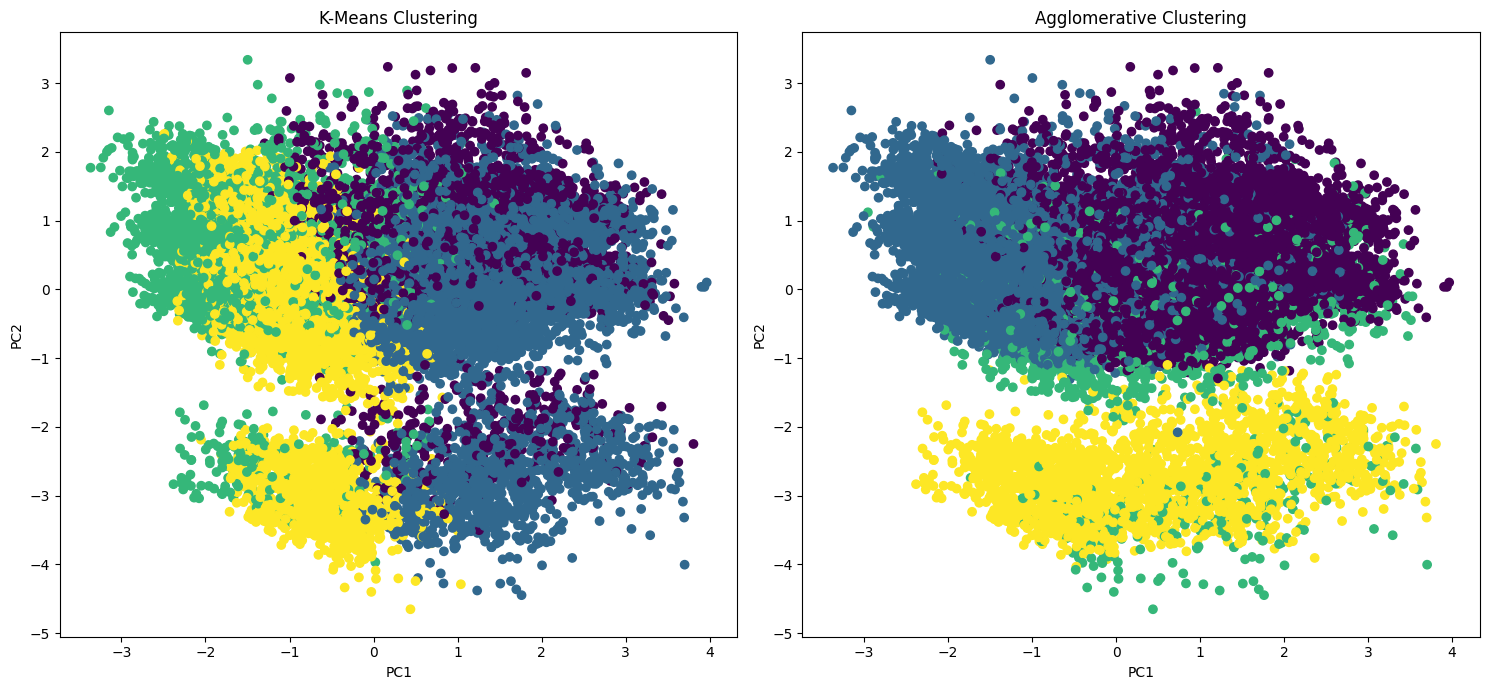

In [36]:
plt.figure(figsize=(15, 7))

plt.subplot(1, 2, 1)
plt.scatter(X_pca[:,0], X_pca[:,1], c=labels)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("K-Means Clustering")

plt.subplot(1, 2, 2)
plt.scatter(X_pca[:,0], X_pca[:,1], c=agg_labels)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Agglomerative Clustering")

plt.tight_layout()
plt.show()

The dataset was cleaned and preprocessed.
Missing values and outliers were handled.
PCA was used to reduce the data dimensions.
K-Means and Agglomerative Clustering were applied.
The clusters were analyzed and compared with income.
The analysis helps to understand different income groups and supports better decision-making.